# Parametric and transport media

`Faraday` is a parametric-instability surface: the chord ratios pick the
unstable wave-numbers via a Mathieu-style dispersion, and the resulting
pattern is a chord-tuned cymatics image. The `transport` family then
takes a wave field (or a chord, auto-wrapped) and redistributes mass or
flow on top of it — sand grains piling on the nodes (`Granular`), tracer
particles flowing along the gradient streamlines (`Tracer`), acoustic
streaming velocities (`Streaming`).

In [1]:
import warnings
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

from biotuner.harmonic_geometry import HarmonicInput, plotting

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

# A small reference set of chord inputs used across the notebook.
CHORDS = {
    "Major": HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(3, 2)]),
    "Sus4":  HarmonicInput(ratios=[Fraction(1), Fraction(4, 3), Fraction(3, 2)]),
    "Dom7":  HarmonicInput(ratios=[Fraction(1), Fraction(5, 4),
                                    Fraction(3, 2), Fraction(7, 4)]),
    "Dim7":  HarmonicInput(ratios=[Fraction(1), Fraction(6, 5),
                                    Fraction(7, 5), Fraction(12, 7)]),
}


## `Faraday` — chord-tuned cymatics patterns

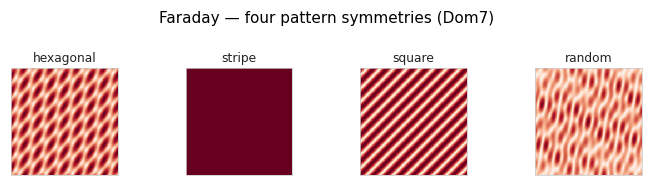

In [2]:
from biotuner.harmonic_geometry.media import Faraday

patterns = ["hexagonal", "stripe", "square", "random"]
geoms = [Faraday(pattern=p, resolution=192, seed=0)(CHORDS["Dom7"])
         for p in patterns]
plotting.gallery(geoms, titles=patterns, n_cols=4,
                 suptitle="Faraday — four pattern symmetries (Dom7)");


## `Granular` — sand-on-plate density across chords

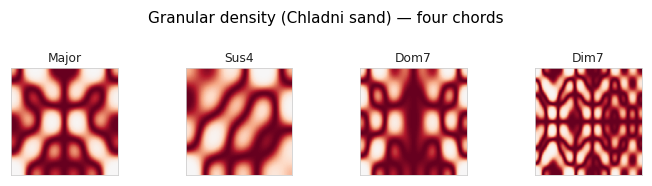

In [3]:
from biotuner.harmonic_geometry.media import Granular, RigidPlate, Pipeline

# Auto-wrap: Granular's default_source is a square RigidPlate.
geoms = [Granular(n_particles=3000, output_mode="density",
                   seed=0)(CHORDS[n]) for n in CHORDS]
plotting.gallery(geoms, titles=list(CHORDS.keys()), n_cols=4,
                 suptitle="Granular density (Chladni sand) — four chords");


### Same chord, two output modes

`output_mode="density"` returns a smoothed 2-D density field;
`output_mode="particles"` returns the raw scatter.

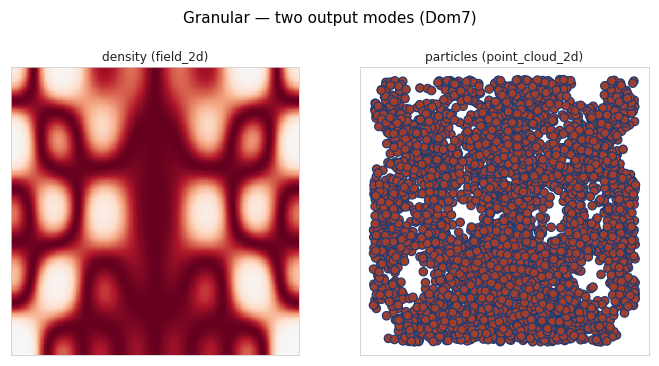

In [4]:
g_density   = Granular(n_particles=4000, output_mode="density",   seed=0)(CHORDS["Dom7"])
g_particles = Granular(n_particles=4000, output_mode="particles", seed=0)(CHORDS["Dom7"])
plotting.gallery([g_density, g_particles],
                 titles=["density (field_2d)", "particles (point_cloud_2d)"],
                 n_cols=2,
                 suptitle="Granular — two output modes (Dom7)");


## `Tracer` — flow streamlines on a wave field

`Tracer` returns either a speed map (``output_mode='speed'``), a tracer
density (``output_mode='tracer_density'``), or the raw 2-D vector field
itself (``output_mode='flow'``). The vector-field output is rendered
with the new ``draw_vector_field_2d`` helper in
:mod:`harmonic_geometry.plotting` — streamlines on a magma background
proportional to the local flow magnitude.

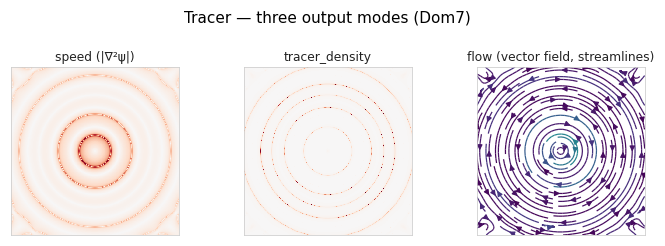

In [5]:
from biotuner.harmonic_geometry.media import Tracer

t_speed   = Tracer(output_mode="speed")(CHORDS["Dom7"])
t_density = Tracer(output_mode="tracer_density")(CHORDS["Dom7"])
t_flow    = Tracer(output_mode="flow")(CHORDS["Dom7"])

plotting.gallery([t_speed, t_density, t_flow],
                 titles=["speed (|∇²ψ|)", "tracer_density",
                         "flow (vector field, streamlines)"],
                 n_cols=3,
                 suptitle="Tracer — three output modes (Dom7)");


## `Streaming` — acoustic-streaming velocity magnitude

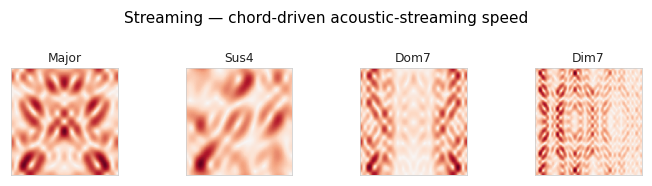

In [6]:
from biotuner.harmonic_geometry.media import Streaming

geoms = [Streaming(output_mode="speed")(CHORDS[n]) for n in CHORDS]
plotting.gallery(geoms, titles=list(CHORDS.keys()), n_cols=4,
                 suptitle="Streaming — chord-driven acoustic-streaming speed");
